# Polynomial Regression, Overfitting and the Bias–Variance Trade-off

> 📖 Book: [ch05 – Features, polynomial regression, overfitting](../../.claude/skills/ml-knowledge/chapters/ch05-features-polynomial-regression-overfitting.md), [ch09 – Diagnostics](../../.claude/skills/ml-knowledge/chapters/ch09-diagnostics-model-selection.md) · Prev: [06](06_multivariate_and_feature_scaling.ipynb) · Next: [08 Review](08_review.ipynb)

## "Linear" means linear in $\theta$

The hypothesis doesn't need to be a straight line. We can create new features from the old ones:

- combine features, e.g. $x_3 = x_1x_2$ (or area = frontage × depth);
- use powers or other fixed functions of a feature:

$$
h_\theta(x) = \theta_0 + \theta_1x + \theta_2x^2 + \theta_3x^3 \qquad \text{or} \qquad h_\theta(x) = \theta_0 + \theta_1x + \theta_2\sqrt{x}.
$$

With $x_1 = x$, $x_2 = x^2$, $x_3 = x^3$ this is an ordinary **multivariate linear regression**: the model is still linear in $\theta$, so the normal equations and gradient descent apply unchanged. Any fixed basis function of $x$ is allowed; $\theta$ must never appear inside a nonlinearity.

$$
X = \begin{pmatrix}
1 & x^{(1)} & (x^{(1)})^2 & \cdots & (x^{(1)})^d \\
\vdots & & & & \vdots \\
1 & x^{(m)} & (x^{(m)})^2 & \cdots & (x^{(m)})^d
\end{pmatrix} \quad \text{(a Vandermonde matrix)}
$$

⚠️ **Feature scaling becomes essential**: if $x \in [1, 1000]$ then $x^2 \in [1, 10^6]$ and $x^3 \in [1, 10^9]$. The Vandermonde matrix is notoriously ill-conditioned.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from ml.features.scaling import polynomial_features, standardize
from ml.linalg import condition_number
from ml.linear_models import add_bias, mse_cost, normal_equations, ridge

plt.style.use("seaborn-v0_8-whitegrid")
rng = np.random.default_rng(3)


def true_f(x):
    return np.sin(2 * np.pi * x)


m = 15
x_train = np.sort(rng.random(m))
y_train = true_f(x_train) + 0.2 * rng.normal(size=m)
x_test = rng.random(200)
y_test = true_f(x_test) + 0.2 * rng.normal(size=200)
xs = np.linspace(0, 1, 400)


def fit_poly(d, lam=0.0):
    """Fit a degree-d polynomial on standardized powers; return a predictor."""
    Z, transform = standardize(polynomial_features(x_train, d))
    X = add_bias(Z)
    theta = ridge(X, y_train, lam) if lam else normal_equations(X, y_train)
    return lambda x: add_bias(transform(polynomial_features(x, d))) @ theta, X, theta

## Underfitting and overfitting

We sample 15 noisy points from $y = \sin(2\pi x)$ and fit polynomials of increasing degree $d$.

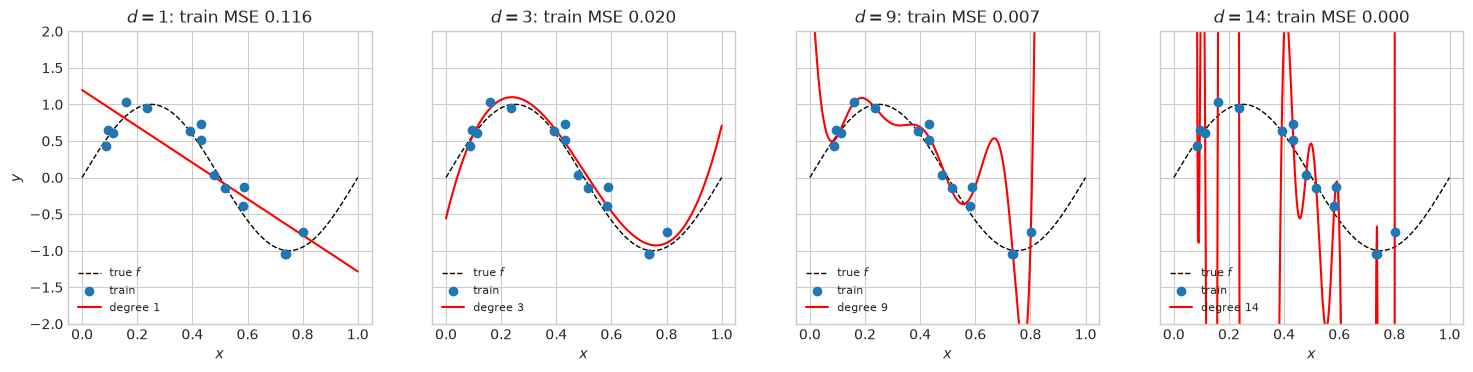

In [2]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.8), sharey=True)
for ax, d in zip(axes, [1, 3, 9, 14], strict=True):
    predict, X, theta = fit_poly(d)
    ax.plot(xs, true_f(xs), "k--", lw=1, label="true $f$")
    ax.scatter(x_train, y_train, zorder=3, label="train")
    ax.plot(xs, predict(xs), "r", label=f"degree {d}")
    ax.set(ylim=(-2, 2), xlabel="$x$",
           title=f"$d = {d}$: train MSE {2 * mse_cost(theta, X, y_train):.3f}")
    ax.legend(loc="lower left", fontsize=8)
axes[0].set_ylabel("$y$")
plt.show()

- $d = 1$: **underfitting / high bias**. The model is too rigid to follow the data; the error is large on train *and* test.
- $d = 3$: about right.
- $d = 9, 14$: **overfitting / high variance**. The curve passes (almost) through every training point, including the noise, and oscillates wildly between them. Train error → 0, test error explodes. With $d = m - 1$ the polynomial interpolates the data exactly.

The wild oscillations near the ends of the interval are the **Runge phenomenon**: high-degree interpolation on equispaced points diverges near the edges.

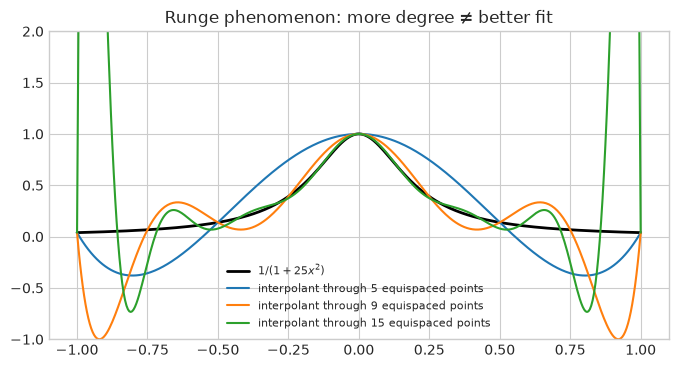

In [3]:
# Runge's classic example: f(x) = 1 / (1 + 25 x^2) on [-1, 1]
runge = lambda x: 1 / (1 + 25 * x**2)  # noqa: E731
xr = np.linspace(-1, 1, 400)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(xr, runge(xr), "k", lw=2, label="$1/(1 + 25x^2)$")
for n_nodes in (5, 9, 15):
    nodes = np.linspace(-1, 1, n_nodes)
    coeffs = np.polyfit(nodes, runge(nodes), n_nodes - 1)
    ax.plot(xr, np.polyval(coeffs, xr), label=f"interpolant through {n_nodes} equispaced points")
ax.set(ylim=(-1, 2), title="Runge phenomenon: more degree ≠ better fit")
ax.legend(fontsize=8)
plt.show()

## Training vs. test error: the bias–variance trade-off

Fit on the training set, evaluate on independent test data. The expected test error decomposes as

$$
\mathbb{E}\left[(y - h(x))^2\right] = \underbrace{\mathrm{Bias}[h(x)]^2}_{\text{model too simple}} + \underbrace{\mathrm{Var}[h(x)]}_{\text{model too flexible}} + \underbrace{\sigma^2}_{\text{noise}} .
$$

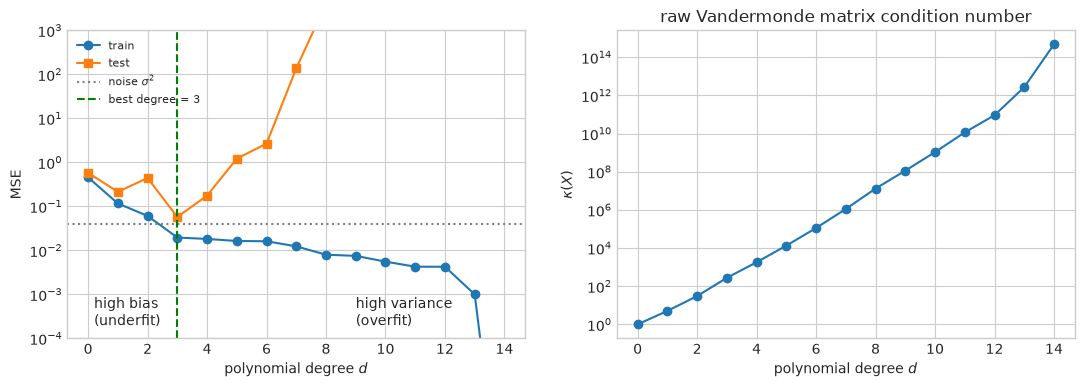

In [4]:
degrees = range(0, 15)
train_err, test_err, kappas = [], [], []
for d in degrees:
    if d == 0:
        predict = lambda x: np.full_like(x, y_train.mean())  # noqa: E731
        kappas.append(1.0)
    else:
        predict, _, _ = fit_poly(d)
        kappas.append(condition_number(add_bias(polynomial_features(x_train, d))))
    train_err.append(np.mean((predict(x_train) - y_train) ** 2))
    test_err.append(np.mean((predict(x_test) - y_test) ** 2))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.semilogy(degrees, train_err, "o-", label="train")
ax1.semilogy(degrees, test_err, "s-", label="test")
ax1.axhline(0.04, c="gray", ls=":", label=r"noise $\sigma^2$")
best = int(np.argmin(test_err))
ax1.axvline(best, c="g", ls="--", label=f"best degree = {best}")
ax1.set(xlabel="polynomial degree $d$", ylabel="MSE", ylim=(1e-4, 1e3))
ax1.text(0.2, 2e-4, "high bias\n(underfit)")
ax1.text(9, 2e-4, "high variance\n(overfit)")
ax1.legend(loc="upper left", fontsize=8)
ax2.semilogy(degrees, kappas, "o-")
ax2.set(xlabel="polynomial degree $d$", ylabel=r"$\kappa(X)$", title="raw Vandermonde matrix condition number")
plt.show()

## A cure for overfitting: regularization

Instead of choosing a small degree, keep the flexible model but penalize large coefficients (ridge / Tikhonov / weight decay):

$$
J(\theta) = \frac{1}{2m}\|X\theta - y\|^2 + \frac{\lambda}{2m}\|\theta\|^2 \quad\Longrightarrow\quad \theta = (X^TX + \lambda I)^{-1}X^Ty .
$$

$\lambda$ trades bias for variance: $\lambda \to 0$ overfits, $\lambda \to \infty$ flattens the model.

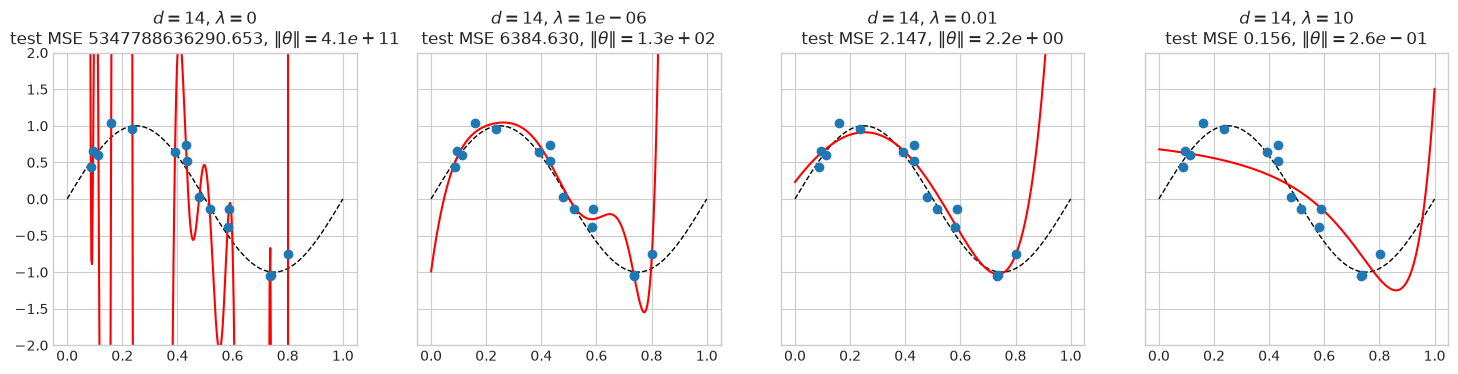

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.8), sharey=True)
for ax, lam in zip(axes, [0, 1e-6, 1e-2, 10], strict=True):
    predict, _, theta = fit_poly(14, lam)
    ax.plot(xs, true_f(xs), "k--", lw=1)
    ax.scatter(x_train, y_train, zorder=3)
    ax.plot(xs, predict(xs), "r")
    test_mse = np.mean((predict(x_test) - y_test) ** 2)
    ax.set(ylim=(-2, 2), title=f"$d = 14$, $\\lambda = {lam:g}$\ntest MSE {test_mse:.3f}, $\\|\\theta\\| = {np.linalg.norm(theta):.1e}$")
plt.show()

**How to pick $d$ or $\lambda$ honestly?** Not on the test set: split into train / cross-validation / test (e.g. 60/20/20) or use $k$-fold CV, choose the hyperparameter on the CV error, and report the test error once. See [05_model_selection](../05_model_selection/02_hyperparameter_tuning.ipynb) and book ch09.

## Summary

- Polynomial (and any basis-function) regression = linear regression on engineered features.
- Scale the features; high powers are ill-conditioned.
- Too simple → high bias; too flexible → high variance. Watch train *and* validation error.
- Regularization ($\lambda$) controls flexibility without changing the feature set.